[*] Extracting and Scaling the 20-Gene Parsimonious Panel...


2026-05-06 15:04:24,188 - harmonypy - INFO - Running Harmony
2026-05-06 15:04:24,191 - harmonypy - INFO -   Parameters:
2026-05-06 15:04:24,191 - harmonypy - INFO -     max_iter_harmony: 20
2026-05-06 15:04:24,192 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-06 15:04:24,193 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-06 15:04:24,193 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-06 15:04:24,194 - harmonypy - INFO -     nclust: 61
2026-05-06 15:04:24,195 - harmonypy - INFO -     block_size: 0.05
2026-05-06 15:04:24,196 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-06 15:04:24,198 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-06 15:04:24,199 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-06 15:04:24,200 - harmonypy - INFO -     verbose: True
2026-05-06 15:04:24,202 - harmonypy - INFO -     random_state: 42
2026-05-06 15:04:24,203 - harmonypy - INFO -   Data: 20 PCs × 1819 cells
2026-05-06 15:04:24,204 - harmony

[*] Executing Harmony directly on the 20-gene biological space...


2026-05-06 15:04:24,466 - harmonypy - INFO - Iteration 7 of 20
2026-05-06 15:04:24,522 - harmonypy - INFO - Iteration 8 of 20
2026-05-06 15:04:24,565 - harmonypy - INFO - Converged after 8 iterations
/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[*] Running UMAP on the True Biological Manifold...
[*] Figure saved to: /workspace/outputs/figures/parsimonious_20gene_umap.png


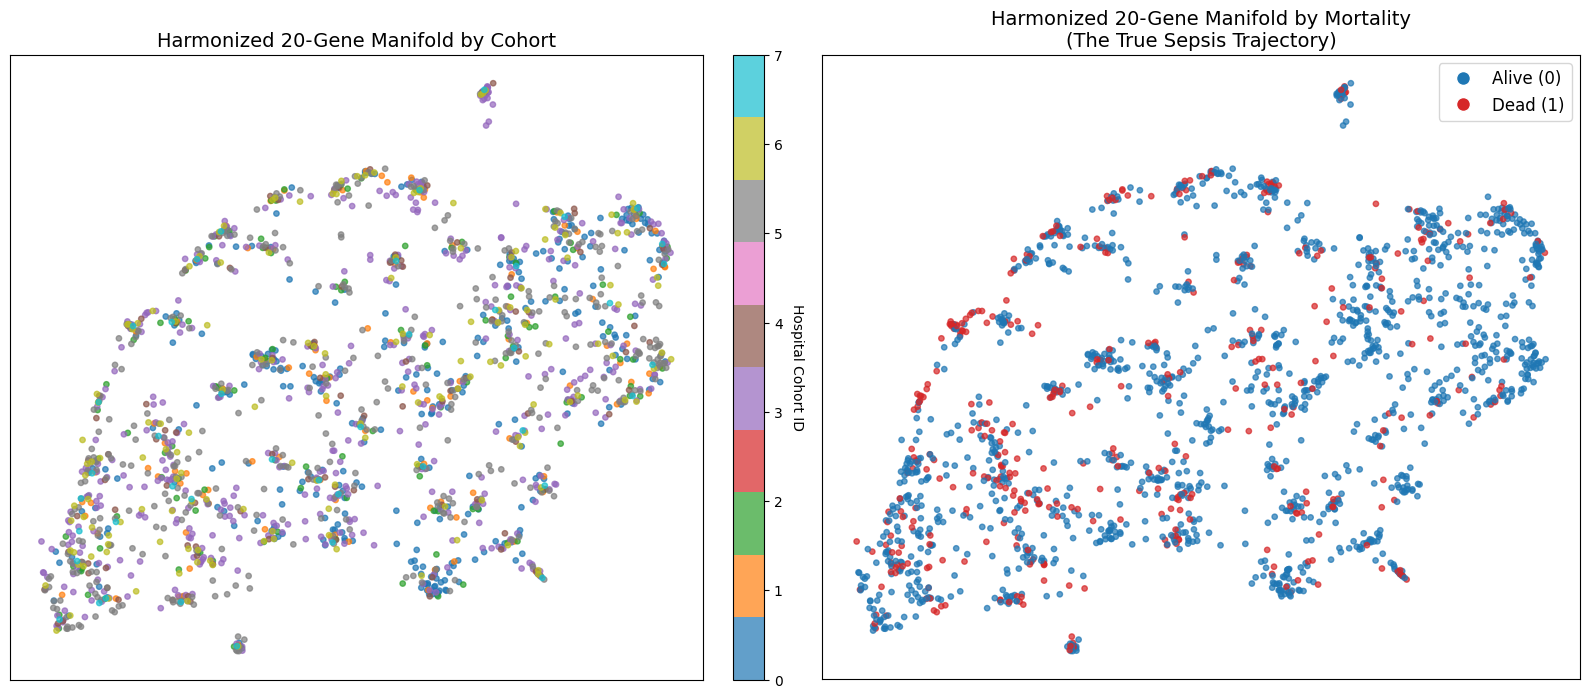

In [4]:
# Cell: The Parsimonious Manifold (20-Gene Integration)
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
import harmonypy as hm
import os

base_dir = "/workspace"
mapped_dir = os.path.join(base_dir, "data/processed/mapped_matrices")
all_cohorts = ['GSE185263', 'GSE26440', 'GSE54514', 'GSE65682', 'GSE95233', 'GSE236713', 'GSE272769', 'GSE69063']

# THE SHAP-DERIVED 20 GENE PANEL (The true biological signal)
core_genes = [
    'PCSK9', 'RORC', 'MAOA', 'TMEM176A', 'NNMT', 'DAAM2', 'KIF20A', 
    'SIPA1L2', 'OLAH', 'LRRN3', 'DDIT4', 'SLC2A14', 'PRTN3', 'TESC', 
    'CCR3', 'SERINC2', 'WASL', 'AEBP1', 'PLEKHH3', 'XIST'
]

print("[*] Extracting and Scaling the 20-Gene Parsimonious Panel...")
y_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/y_master.csv"))
meta_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/meta_master.csv"))
meta_master["Patient_ID"] = meta_master["Patient_ID"].astype(str).str.strip()
label_dict = dict(zip(meta_master["Patient_ID"], y_master["Mortality"]))

all_X_scaled, all_domains, all_labels = [], [], []

for domain_idx, cohort in enumerate(all_cohorts):
    file_path = os.path.join(mapped_dir, f"{cohort}_mapped.csv.gz")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col=0).T
        df.index = df.index.astype(str).str.strip()
        df["Mortality"] = df.index.map(label_dict)
        df = df.dropna(subset=["Mortality"])
        
        # Ensure the 20 genes exist, zero-fill if a specific older array missed one
        for gene in core_genes:
            if gene not in df.columns:
                df[gene] = 0.0
                
        # ONLY EXTRACT THE 20 GENES
        raw_data = df[core_genes].astype('float32').values
        
        # Independent Cohort Scaling (Crucial for Batch Effects)
        scaler = StandardScaler()
        hospital_scaled_data = scaler.fit_transform(raw_data)
        
        all_X_scaled.append(hospital_scaled_data)
        all_domains.append(np.full(len(df), domain_idx))
        all_labels.append(df["Mortality"].values)

final_scaled_X = np.vstack(all_X_scaled)
domain_array = np.concatenate(all_domains)
label_array = np.concatenate(all_labels)
meta_df = pd.DataFrame({'hospital_cohort': domain_array})

# Because we only have 20 dimensions, we skip PCA and let Harmony align the genes directly
print("[*] Executing Harmony directly on the 20-gene biological space...")
harmony_out = hm.run_harmony(
    final_scaled_X,  # <-- Passing the 20 genes directly
    meta_df, 
    vars_use='hospital_cohort',
    max_iter_harmony=20,
    random_state=42
)

harmonized_space = harmony_out.Z_corr
if harmonized_space.shape[0] != final_scaled_X.shape[0]: 
    harmonized_space = harmonized_space.T 

print("[*] Running UMAP on the True Biological Manifold...")
reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=42)
umap_harmonized = reducer.fit_transform(harmonized_space)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = axes[0].scatter(
    umap_harmonized[:, 0], umap_harmonized[:, 1],
    c=domain_array, cmap='tab10', s=15, alpha=0.7
)
axes[0].set_title("Harmonized 20-Gene Manifold by Cohort", fontsize=14)
axes[0].set_xticks([]); axes[0].set_yticks([])
cbar1 = fig.colorbar(scatter1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Hospital Cohort ID', rotation=270, labelpad=15)

cmap_mortality = mcolors.ListedColormap(['#1f77b4', '#d62728']) 
scatter2 = axes[1].scatter(
    umap_harmonized[:, 0], umap_harmonized[:, 1],
    c=label_array, cmap=cmap_mortality, s=15, alpha=0.7
)
axes[1].set_title("Harmonized 20-Gene Manifold by Mortality\n(The True Sepsis Trajectory)", fontsize=14)
axes[1].set_xticks([]); axes[1].set_yticks([])

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Alive (0)', markerfacecolor='#1f77b4', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Dead (1)', markerfacecolor='#d62728', markersize=10)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

# --- Added Saving Logic ---
fig_dir = os.path.join(base_dir, "outputs/figures")
os.makedirs(fig_dir, exist_ok=True)
save_path = os.path.join(fig_dir, "parsimonious_20gene_umap.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved to: {save_path}")
# --------------------------

plt.show()